In [6]:
import matplotlib.pyplot as plt

%matplotlib inline

plt.figure(figsize=(20, 5))


<Figure size 2000x500 with 0 Axes>

<Figure size 2000x500 with 0 Axes>

In [7]:
from astropy.io import fits

with fits.open("/Users/wayfinder/Code/fault-in-our-stars/assets/test/kplr003863594-2009131105131_llc.fits") as hdul:
    hdul.info()
    data = hdul[1].data
    print(data.columns.names)


Filename: /Users/wayfinder/Code/fault-in-our-stars/assets/test/kplr003863594-2009131105131_llc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      58   ()      
  1  LIGHTCURVE    1 BinTableHDU    155   476R x 20C   [D, E, J, E, E, E, E, E, E, J, D, E, D, E, D, E, D, E, E, E]   
  2  APERTURE      1 ImageHDU        48   (10, 7)   int32   
['TIME', 'TIMECORR', 'CADENCENO', 'SAP_FLUX', 'SAP_FLUX_ERR', 'SAP_BKG', 'SAP_BKG_ERR', 'PDCSAP_FLUX', 'PDCSAP_FLUX_ERR', 'SAP_QUALITY', 'PSF_CENTR1', 'PSF_CENTR1_ERR', 'PSF_CENTR2', 'PSF_CENTR2_ERR', 'MOM_CENTR1', 'MOM_CENTR1_ERR', 'MOM_CENTR2', 'MOM_CENTR2_ERR', 'POS_CORR1', 'POS_CORR2']


In [8]:
from pathlib import Path
import lightkurve as lk

def kic_to_9digits(kic):
    return f"{int(kic):09d}"

def find_kic_fits_files(kic, folder):
    folder = Path(folder)
    kic9 = kic_to_9digits(kic)

    if not folder.exists():
        raise FileNotFoundError(f"Folder does not exist: {folder}")

    # Search recursively, then match by filename prefix
    files = sorted(
        p for p in folder.rglob("*.fits")
        if p.name.startswith(f"kplr{kic9}-") and p.name.endswith("_llc.fits")
    )

    return files

def load_kic_lightcurves(kic, folder, remove_nans=True):
    files = find_kic_fits_files(kic, folder)

    if not files:
        raise FileNotFoundError(
            f"No FITS files found for KIC {kic} in {folder}. "
            f"Expected names like kplr{kic_to_9digits(kic)}-*_llc.fits"
        )

    lcs = []
    for file in files:
        lc = lk.read(file)
        if remove_nans:
            lc = lc.remove_nans()
        lcs.append(lc)

    return lcs

def stitch_kic_lightcurve(kic, folder, normalize=False, remove_nans=True):
    """
    Load all light curves for one KIC and stitch them into one LightCurve.
    """
    lcs = load_kic_lightcurves(kic, folder, remove_nans=remove_nans)

    if normalize:
        lcs = [lc.normalize() for lc in lcs]

    stitched = lk.LightCurveCollection(lcs).stitch()
    stitched = stitched.remove_nans()

    return stitched


[PosixPath('/Users/wayfinder/Code/fault-in-our-stars/assets/test/kplr008912468-2009131105131_llc.fits'), PosixPath('/Users/wayfinder/Code/fault-in-our-stars/assets/test/kplr008912468-2009166043257_llc.fits'), PosixPath('/Users/wayfinder/Code/fault-in-our-stars/assets/test/kplr008912468-2009259160929_llc.fits'), PosixPath('/Users/wayfinder/Code/fault-in-our-stars/assets/test/kplr008912468-2009350155506_llc.fits'), PosixPath('/Users/wayfinder/Code/fault-in-our-stars/assets/test/kplr008912468-2010078095331_llc.fits'), PosixPath('/Users/wayfinder/Code/fault-in-our-stars/assets/test/kplr008912468-2010174085026_llc.fits'), PosixPath('/Users/wayfinder/Code/fault-in-our-stars/assets/test/kplr008912468-2010265121752_llc.fits'), PosixPath('/Users/wayfinder/Code/fault-in-our-stars/assets/test/kplr008912468-2010355172524_llc.fits'), PosixPath('/Users/wayfinder/Code/fault-in-our-stars/assets/test/kplr008912468-2011073133259_llc.fits'), PosixPath('/Users/wayfinder/Code/fault-in-our-stars/assets/test

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

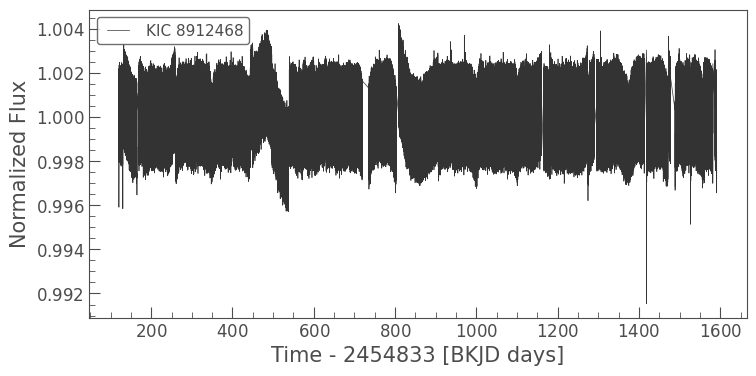

In [10]:
# kic = 3863594
kic = 8912468
folder = "/Users/wayfinder/Code/fault-in-our-stars/assets/test"

files = find_kic_fits_files(kic, folder)
print(files)

stitched_lc = stitch_kic_lightcurve(kic, folder, normalize=True)
stitched_lc.plot()
